<a href="https://colab.research.google.com/github/adrianhernr/SuperconductingQComputing/blob/main/Quantum%20LC%20Circuit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Simulación de la función de onda cuántica de un circuito LC cuántico en sus primeros estados**

Para simular los estados cuánticos excitados superiores (\(n=1\) y \(n=2\)), necesitamos incorporar los polinomios de Hermite (\(H_{n}\)) en la ecuación de la función de onda.A medida que el número cuántico \(n\) aumenta, el circuito absorbe energía en forma de fotones de microondas (\(\hbar\omega_0\)). Físicamente, verás que la carga eléctrica en el capacitor empieza a alejarse del centro (cero) y comienzan a aparecer nodos (puntos donde la probabilidad de encontrar carga es exactamente cero), asemejándose cada vez más a una oscilación clásica de ida y vuelta.

<>:53: SyntaxWarning: invalid escape sequence '\p'
<>:53: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_15797/2475028860.py:53: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Densidad de Probabilidad $|\psi_n(q)|^2$', fontsize=11)


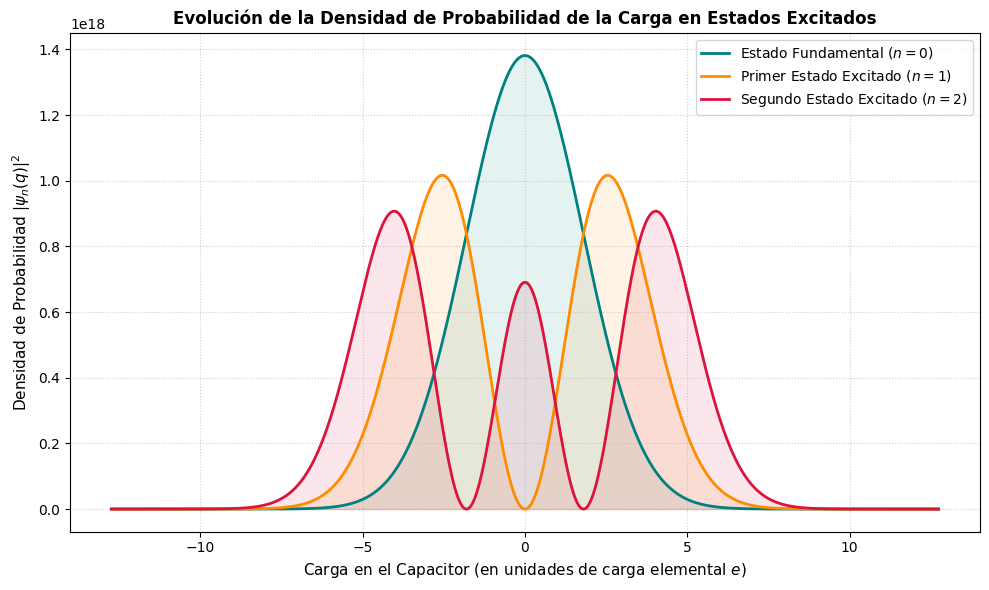

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const
from scipy.special import hermite
from math import factorial

# 1. Parámetros del circuito LC cuántico
L = 10e-9      # Inductancia: 10 nH
C = 100e-15    # Capacitancia: 100 fF
hbar = const.hbar
e = const.e

# 2. Frecuencia y dispersión de carga cuántica (punto cero)
omega_0 = 1 / np.sqrt(L * C)
sigma_q = np.sqrt((hbar * omega_0 * C) / 2)

# 3. Definición del espacio de carga (eje X, extendido a 5 sigma para ver los estados altos)
q_grid = np.linspace(-5 * sigma_q, 5 * sigma_q, 1000)
q_en_e = q_grid / e  # Convertido a unidades de carga elemental

# 4. Función para calcular la densidad de probabilidad |Ψ_n(q)|^2
def densidad_probabilidad_quantum(n, q, sigma):
    # Evalúa el polinomio de Hermite de orden n en el punto q/sigma
    H_n = hermite(n)
    coef_normalizacion = 1 / np.sqrt(2**n * factorial(n)) * (1 / (np.pi * sigma**2))**(0.25)

    psi_n = coef_normalizacion * H_n(q / sigma) * np.exp(-(q**2) / (2 * sigma**2))
    return psi_n**2

# 5. Calcular los datos para n = 0, 1, 2
prob_n0 = densidad_probabilidad_quantum(0, q_grid, sigma_q)
prob_n1 = densidad_probabilidad_quantum(1, q_grid, sigma_q)
prob_n2 = densidad_probabilidad_quantum(2, q_grid, sigma_q)

# 6. Graficar los resultados
plt.figure(figsize=(10, 6))

# Estado Fundamental (n=0)
plt.plot(q_en_e, prob_n0, color='teal', lw=2, label='Estado Fundamental ($n=0$)')
plt.fill_between(q_en_e, prob_n0, color='teal', alpha=0.1)

# Primer Estado Excitado (n=1)
plt.plot(q_en_e, prob_n1, color='darkorange', lw=2, label='Primer Estado Excitado ($n=1$)')
plt.fill_between(q_en_e, prob_n1, color='darkorange', alpha=0.1)

# Segundo Estado Excitado (n=2)
plt.plot(q_en_e, prob_n2, color='crimson', lw=2, label='Segundo Estado Excitado ($n=2$)')
plt.fill_between(q_en_e, prob_n2, color='crimson', alpha=0.1)

# Configuración estética de la gráfica
plt.title('Evolución de la Densidad de Probabilidad de la Carga en Estados Excitados', fontsize=12, fontweight='bold')
plt.xlabel('Carga en el Capacitor (en unidades de carga elemental $e$)', fontsize=11)
plt.ylabel('Densidad de Probabilidad $|\psi_n(q)|^2$', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Si continuáramos subiendo el número cuántico (\(n = 10, 50, 100\)), la acumulación de picos recrearía perfectamente los extremos de una oscilación sinusoidal clásica.

**Circuito LC cuántico no lineal**

Al incorporar una unión Josephson en lugar de la bobina tradicional, transformamos el circuito LC en un circuito cuántico no lineal (el diseño básico de un cúbit superconductor tipo Transmon).La unión Josephson actúa como un "inductor no lineal" que destruye el espaciado uniforme de los niveles de energía. Esto nos permite aislar únicamente los dos primeros estados cuánticos.

<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_15797/915491159.py:64: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('Fase Cuántica / Flujo Magnético ($\phi$)', fontsize=11)


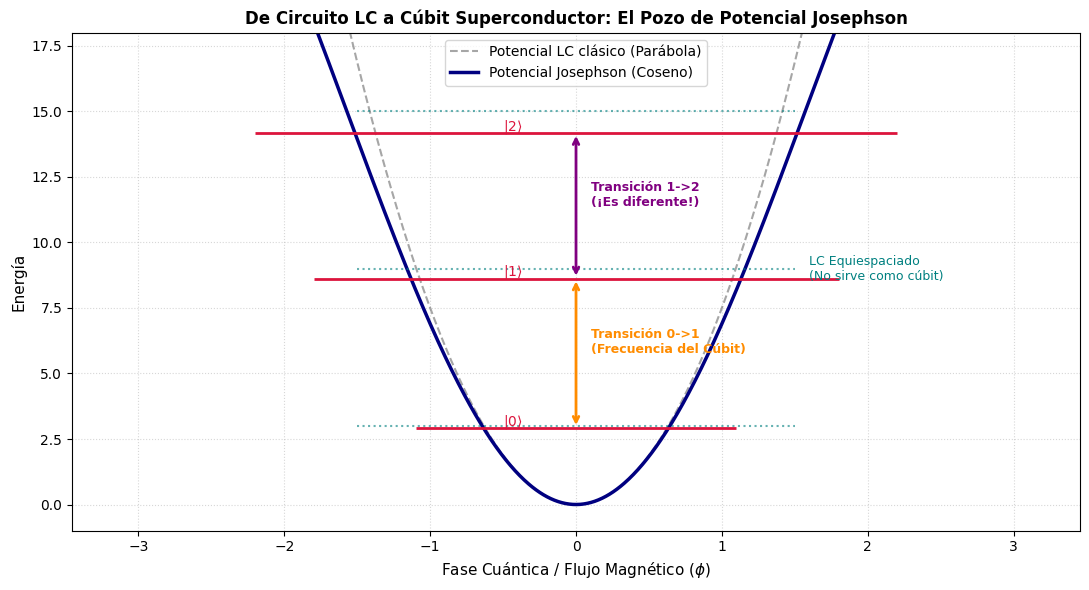

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de parámetros de energía para el cúbit Transmon (en unidades arbitrarias de frecuencia)
E_C = 0.3   # Energía de carga
E_J = 15.0  # Energía de Josephson (En el Transmon, E_J >> E_C para mitigar ruido de carga)

# 2. Definición del eje del flujo / fase cuántica (phi)
phi = np.linspace(-np.pi, np.pi, 1000)

# 3. Potenciales: LC Armónico vs Unión Josephson Anarmónico
# Para comparar de forma justa, expandimos el coseno en serie de Taylor: cos(x) ≈ 1 - x^2/2 + x^4/24
# El término cuadrático representa la aproximación armónica (el circuito LC equivalente)
potencial_LC = 0.5 * E_J * phi**2
potencial_Josephson = E_J * (1 - np.cos(phi))

# 4. Cálculo aproximado de los primeros niveles de energía (Teoría de perturbaciones)
# Frecuencia de transición base (omega_01)
omega_p = np.sqrt(8 * E_C * E_J)
anarmonicidad = -E_C  # La no-linealidad reduce la energía de los niveles superiores

# Niveles para el circuito LC armónico (espaciado constante)
E_LC_0 = 0.5 * omega_p
E_LC_1 = 1.5 * omega_p
E_LC_2 = 2.5 * omega_p

# Niveles para el circuito con Unión Josephson (Anarmónico)
E_J_0 = 0.5 * omega_p - (E_C / 4)
E_J_1 = 1.5 * omega_p - (E_C * 1.25)
E_J_2 = 2.5 * omega_p - (E_C * 2.75)

# 5. Graficar la estructura de energía del cúbit
plt.figure(figsize=(11, 6))

# Dibujar los pozos de potencial
plt.plot(phi, potencial_LC, '--', color='gray', alpha=0.7, label='Potencial LC clásico (Parábola)')
plt.plot(phi, potencial_Josephson, color='navy', lw=2.5, label='Potencial Josephson (Coseno)')

# Dibujar niveles de energía del circuito LC (Armónico)
plt.hlines([E_LC_0, E_LC_1, E_LC_2], -1.5, 1.5, colors='teal', linestyles=':', alpha=0.6)
plt.text(1.6, E_LC_1, 'LC Equiespaciado\n(No sirve como cúbit)', color='teal', va='center', fontsize=9)

# Dibujar niveles de energía de la Unión Josephson (Anarmónico)
plt.hlines(E_J_0, -1.1, 1.1, colors='crimson', lw=2)
plt.hlines(E_J_1, -1.8, 1.8, colors='crimson', lw=2)
plt.hlines(E_J_2, -2.2, 2.2, colors='crimson', lw=2)

# Etiquetas de transiciones
plt.text(-0.5, E_J_0 + 0.1, r'$|0\rangle$', color='crimson', weight='bold')
plt.text(-0.5, E_J_1 + 0.1, r'$|1\rangle$', color='crimson', weight='bold')
plt.text(-0.5, E_J_2 + 0.1, r'$|2\rangle$', color='crimson', weight='bold')

# Flechas que muestran la diferencia de espaciado (Anarmonicidad)
diff_01 = E_J_1 - E_J_0
diff_12 = E_J_2 - E_J_1
plt.annotate('', xy=(0, E_J_1), xytext=(0, E_J_0), arrowprops=dict(arrowstyle="<->", color='darkorange', lw=2))
plt.annotate('', xy=(0, E_J_2), xytext=(0, E_J_1), arrowprops=dict(arrowstyle="<->", color='purple', lw=2))

plt.text(0.1, (E_J_0 + E_J_1)/2, f'Transición 0->1\n(Frecuencia del Cúbit)', color='darkorange', weight='bold', fontsize=9)
plt.text(0.1, (E_J_1 + E_J_2)/2, f'Transición 1->2\n(¡Es diferente!)', color='purple', weight='bold', fontsize=9)

# Configuración estética
plt.title('De Circuito LC a Cúbit Superconductor: El Pozo de Potencial Josephson', fontsize=12, fontweight='bold')
plt.xlabel('Fase Cuántica / Flujo Magnético ($\phi$)', fontsize=11)
plt.ylabel('Energía', fontsize=11)
plt.ylim(-1, E_J + 3)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper center')

plt.tight_layout()
plt.show()

Como la energía necesaria para saltar del estado 0 a 1 es mayor que la necesaria para saltar del estado 1 al 2, un pulso láser de microondas calibrado a la frecuencia exacta del cúbit alterará los estados 0 y 1 sin interactuar jamás con el estado 2. Conseguimos un sistema de dos niveles (un bit cuántico) utilizando un circuito macroscópico.